# House Prices - Advanced Regression Techniques

## Goal 
*  Predict the sales price for each house.
*  For each Id in the test set, we predict the value of the SalePrice variable.     

## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">

<font size = 3>
    
1. <a href="#item31">Download and Explore the data</a>  
2. <a href="#item32">Visualize Features</a>
3. <a href="#item33">Build The Model</a>
4. <a href="#item34">Train and Test the Model</a>  

</font>
</div>

## Download and Explore the data


In [8]:
# Import Needed Libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import norm
import os
import warnings

from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter("ignore", category=ConvergenceWarning)

pd.pandas.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [9]:
# 1) Imports + config
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_log_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [10]:
# Load Data

def load_data():
    for dirname, _, filenames in os.walk('/kaggle/input/house-prices-advanced-regression-techniques'):
        for filename in filenames:
            print(os.path.join(dirname, filename))    
    train_path= os.path.join(dirname, "train.csv")
    test_path= os.path.join(dirname, "test.csv")
    # 1. Read the files into DataFrames
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    
    data_frame = pd.concat([train_df, test_df], ignore_index=True)
    return data_frame, train_df, test_df

data_frame, df, test_path = load_data()


/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [11]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [12]:
# Check any missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Clean the Data

In [13]:
# Count missing values in each column
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # only columns with missing values
print(missing_values.sort_values(ascending=False))


zero_counts = (df == 0).sum()
zero_counts = zero_counts[zero_counts > 0]  # only columns with missing values
print("-----------------------------")
print("zero_counts: \n", zero_counts)


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64
-----------------------------
zero_counts: 
 MasVnrArea        861
BsmtFinSF1        467
BsmtFinSF2       1293
BsmtUnfSF         118
TotalBsmtSF        37
2ndFlrSF          829
LowQualFinSF     1434
BsmtFullBath      856
BsmtHalfBath     1378
FullBath            9
HalfBath          913
BedroomAbvGr        6
KitchenAbvGr        1
Fireplaces        690
GarageCars         81
GarageArea         81
WoodDeckSF        761
OpenPorchSF       656
EnclosedPorch    1252
3SsnPorch        1436
ScreenPorch      1344
PoolArea         1453
MiscVal          1408
dtype: int64


In [14]:
#Drop columns with too many missing values:
threshold = 0.5  # drop columns with >50% missing values
df = df.loc[:, df.isnull().mean() < threshold]
print(df)
#Drop rows with missing values:
#df = df.dropna()

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street LotShape  \
0        1          60       RL       65.000     8450   Pave      Reg   
1        2          20       RL       80.000     9600   Pave      Reg   
2        3          60       RL       68.000    11250   Pave      IR1   
3        4          70       RL       60.000     9550   Pave      IR1   
4        5          60       RL       84.000    14260   Pave      IR1   
...    ...         ...      ...          ...      ...    ...      ...   
1455  1456          60       RL       62.000     7917   Pave      Reg   
1456  1457          20       RL       85.000    13175   Pave      Reg   
1457  1458          70       RL       66.000     9042   Pave      Reg   
1458  1459          20       RL       68.000     9717   Pave      Reg   
1459  1460          20       RL       75.000     9937   Pave      Reg   

     LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0            Lvl    AllPub    Inside       Gtl   

In [15]:
# Count missing values in each column
missing_percent = df.isnull().mean() * 100# Calculate missing percentage per column

# Keep only columns with missing values
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)# Step 3: Sort descending to see columns with most missing values first
print(missing_percent)

FireplaceQu    47.260
LotFrontage    17.740
GarageYrBlt     5.548
GarageFinish    5.548
GarageType      5.548
GarageQual      5.548
GarageCond      5.548
BsmtExposure    2.603
BsmtFinType2    2.603
BsmtCond        2.534
BsmtQual        2.534
BsmtFinType1    2.534
MasVnrArea      0.548
Electrical      0.068
dtype: float64


In [16]:
##  Check the size of the data points
df.shape

(1460, 76)

**Comment**: \
There are approximately 1050 samples to train our model on. Because of the few samples, we have to be careful not to overfit the training data.

In [17]:
### Explore the data
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000,1460.000,1201.000,1460.000,1460.000,1460.000,1460.000,1460.000,1452.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1379.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000
mean,730.500,56.897,70.050,10516.828,6.099,5.575,1971.268,1984.866,103.685,443.640,46.549,567.240,1057.429,1162.627,346.992,5.845,1515.464,0.425,0.058,1.565,0.383,2.866,1.047,6.518,0.613,1978.506,1.767,472.980,94.245,46.660,21.954,3.410,15.061,2.759,43.489,6.322,2007.816,180921.196
std,421.610,42.301,24.285,9981.265,1.383,1.113,30.203,20.645,181.066,456.098,161.319,441.867,438.705,386.588,436.528,48.623,525.480,0.519,0.239,0.551,0.503,0.816,0.220,1.625,0.645,24.690,0.747,213.805,125.339,66.256,61.119,29.317,55.757,40.177,496.123,2.704,1.328,79442.503
min,1.000,20.000,21.000,1300.000,1.000,1.000,1872.000,1950.000,0.000,0.000,0.000,0.000,0.000,334.000,0.000,0.000,334.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,1900.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,2006.000,34900.000
25%,365.750,20.000,59.000,7553.500,5.000,5.000,1954.000,1967.000,0.000,0.000,0.000,223.000,795.750,882.000,0.000,0.000,1129.500,0.000,0.000,1.000,0.000,2.000,1.000,5.000,0.000,1961.000,1.000,334.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.000,2007.000,129975.000
50%,730.500,50.000,69.000,9478.500,6.000,5.000,1973.000,1994.000,0.000,383.500,0.000,477.500,991.500,1087.000,0.000,0.000,1464.000,0.000,0.000,2.000,0.000,3.000,1.000,6.000,1.000,1980.000,2.000,480.000,0.000,25.000,0.000,0.000,0.000,0.000,0.000,6.000,2008.000,163000.000
75%,1095.250,70.000,80.000,11601.500,7.000,6.000,2000.000,2004.000,166.000,712.250,0.000,808.000,1298.250,1391.250,728.000,0.000,1776.750,1.000,0.000,2.000,1.000,3.000,1.000,7.000,1.000,2002.000,2.000,576.000,168.000,68.000,0.000,0.000,0.000,0.000,0.000,8.000,2009.000,214000.000
max,1460.000,190.000,313.000,215245.000,10.000,9.000,2010.000,2010.000,1600.000,5644.000,1474.000,2336.000,6110.000,4692.000,2065.000,572.000,5642.000,3.000,2.000,3.000,2.000,8.000,3.000,14.000,3.000,2010.000,4.000,1418.000,857.000,547.000,552.000,508.000,480.000,738.000,15500.000,12.000,2010.000,755000.000


**Comment**  
1. __MSSubClass__ : is categorical  stored as numeric I am not going to consider it for outliers
2. __SalePrice__ : The mean (180921) > median (163000), indicating a right-skewed distribution.\
 a. The Gap between min price 34900 and max price 755000 indicates a high spread of data.\
 b. Most houses (about 75%) have a sale price of 214000 and the max price is 755000. This  pulls the mean upward.
3. __LotArea__ : The std  is very high, it is even close to the mean \
   a. One house has max = 215245 >20x the typical lot size (10516).\
   b. Indicates outliers
4. __MasVnrArea__ (Masonry veneer area):  large masonry veneer Max: 1,600 while is mean: 103.6\
   a. Indicates a Large Luxury Home

5. __BsmtFinSF1__ & __BsmtFinSF2__ are the ratings of the primary and secondary finished area of a basement\
    a. One house has max = 5644 which is 13x the typical rating (443).\
    b. Indicates outliers

6. __3SsnPorch__: Three season porch area in square feet \
    a. One house has max = 508 which is 13x the typical rating (3) \
    b. Indicates a Large Luxury Home

## Visualize features

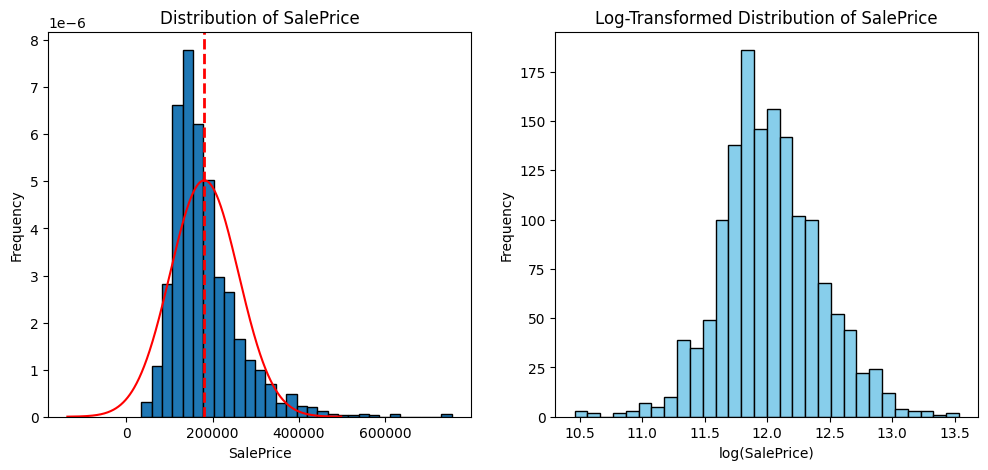

In [18]:
# Given statistics
mean = df['SalePrice'].mean()
std = df['SalePrice'].std()
# Generate x values (±4 standard deviations)
x = np.linspace(mean - 4*std, mean + 4*std, 1000)
# Normal distribution PDF
y = norm.pdf(x, loc=mean, scale=std)

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['SalePrice'], bins=30, density=True, edgecolor='black')
# vertical reference lines
axes[0].axvline(mean, linestyle='--', linewidth=2, label=f'Mean = {mean:,.0f}', color="r")
axes[0].plot(x, y, color="r")
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of SalePrice')

# normalized Log SalePrice
axes[1].hist(np.log1p(df['SalePrice']), bins=30, color='skyblue', edgecolor='black')
axes[1].set_title('Log-Transformed Distribution of SalePrice')
axes[1].set_xlabel('log(SalePrice)')
axes[1].set_ylabel('Frequency')
plt.show()

LotFrontage: 88 outliers with spread ratio 0.072 (313.00, 70.05)
LotArea: 69 outliers with spread ratio 0.019 (215,245.00, 10,516.83)
OverallQual: 2 outliers with spread ratio 0.222 (10.00, 6.10)
OverallCond: 125 outliers with spread ratio 0.125 (9.00, 5.58)
YearBuilt: 7 outliers with spread ratio 0.333 (2,010.00, 1,971.27)
YearRemodAdd: 0 outliers with  spread ratio  0.617
MasVnrArea: 96 outliers with spread ratio 0.104 (1,600.00, 103.69)
BsmtFinSF1: 7 outliers with spread ratio 0.126 (5,644.00, 443.64)
BsmtFinSF2: 167 outliers with  spread ratio  0.000
BsmtUnfSF: 29 outliers with spread ratio 0.250 (2,336.00, 567.24)
TotalBsmtSF: 61 outliers with spread ratio 0.082 (6,110.00, 1,057.43)
1stFlrSF: 20 outliers with spread ratio 0.117 (4,692.00, 1,162.63)
2ndFlrSF: 2 outliers with spread ratio 0.353 (2,065.00, 346.99)
LowQualFinSF: 26 outliers with  spread ratio  0.000
GrLivArea: 31 outliers with spread ratio 0.122 (5,642.00, 1,515.46)
BsmtFullBath: 1 outliers with spread ratio 0.333 (3.

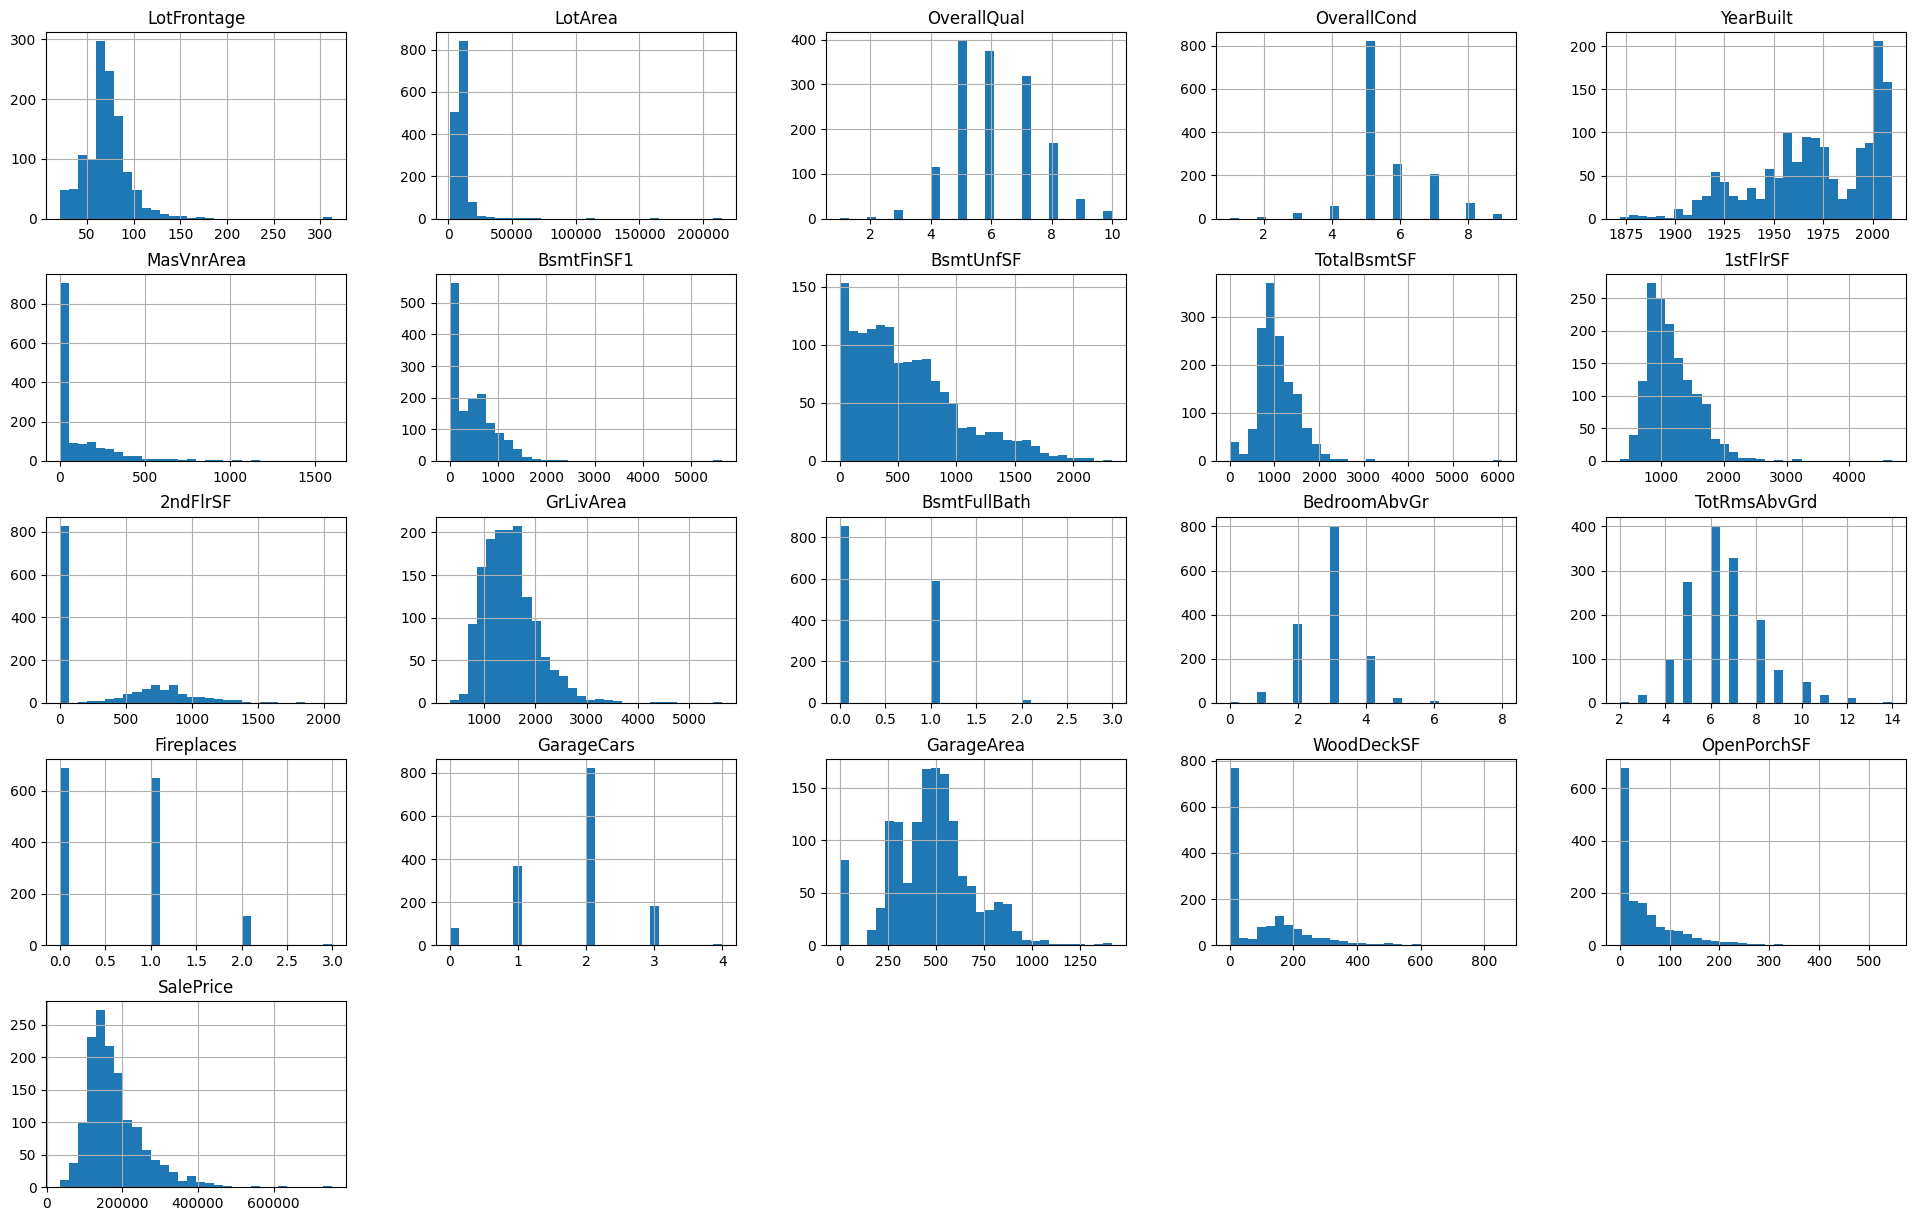

In [19]:
outliers_dict ={}
def get_outliers(df =None, col=None,boundaries= 1.5, outlier_threshold=1):
    df_drop = df[col].dropna()
    # Calculates Q1, Q3, and IQR for each numeric column.
    Q3 = df_drop.quantile(0.75)
    Q1 = df_drop.quantile(0.25)
    IQR = Q3 - Q1
    # Define outlier boundaries
    # Flags values 1.5×IQR below Q1 or above Q3 as outliers.
    lower_bound = Q1 - boundaries * IQR
    upper_bound = Q3 + boundaries * IQR
    bounded_df= df_drop[(df_drop < lower_bound) | (df_drop > upper_bound)]
    # measures how far the mean is from the maximum relative to max.
    range_ = df_drop.max() - df_drop.min()
    spread_ratio = IQR / range_ if range_ != 0 else 0
    if  len(bounded_df) >= outlier_threshold and spread_ratio !=0:
        print(f"\033[91m{col}: {len(bounded_df)} outliers with spread ratio {spread_ratio:,.3f} ({df_drop.max():,.2f}, {df_drop.mean():,.2f})\033[0m")
        outliers_dict[col] = bounded_df
    else:
        print(f"\033[92m{col}: {len(bounded_df)} outliers with  spread ratio  {spread_ratio:,.3f}\033[0m")
    return bounded_df

# Call for each numeric column
# Prepare data, drop NaNs for each feature
for col in df.select_dtypes(include=np.number).columns[2:]: # Ignore Id and MSSubClass
    #Whiskers → Usually 1.5 × IQR beyond quartiles
    outlier_indices = get_outliers(df, col,1.5,1)

features = list(outliers_dict.keys())
# Extract the data for boxplots as a list of arrays
viz = df[features]
viz.hist(figsize=(24, 15), bins=30)
plt.show()

**Comment**  
1. __MiscVal ,  BsmtFinSF2 ,  LowQualFinSF ,  PoolArea ,  3SsnPorch ,  ScreenPorch, EnclosedPorch, BsmtHalfBath__ : is mostly zeros, with a few very high values \
 a. That is why spread_ratio formula can be misleading. as the spread_ratio = 0 / (max - min) = 0 \
 b. Extreme outliers
3. __GarageArea__: Most of the houses have Garage areas between 400 -800
4. __GrLivArea__: Above grade (ground) living area square feet beteen 4000 -500
5. Features with large std may:\
   a. Have extreme outliers (LotArea, BsmtFinSF1, MasVnrArea)\
   b. Need log transformation for regression models

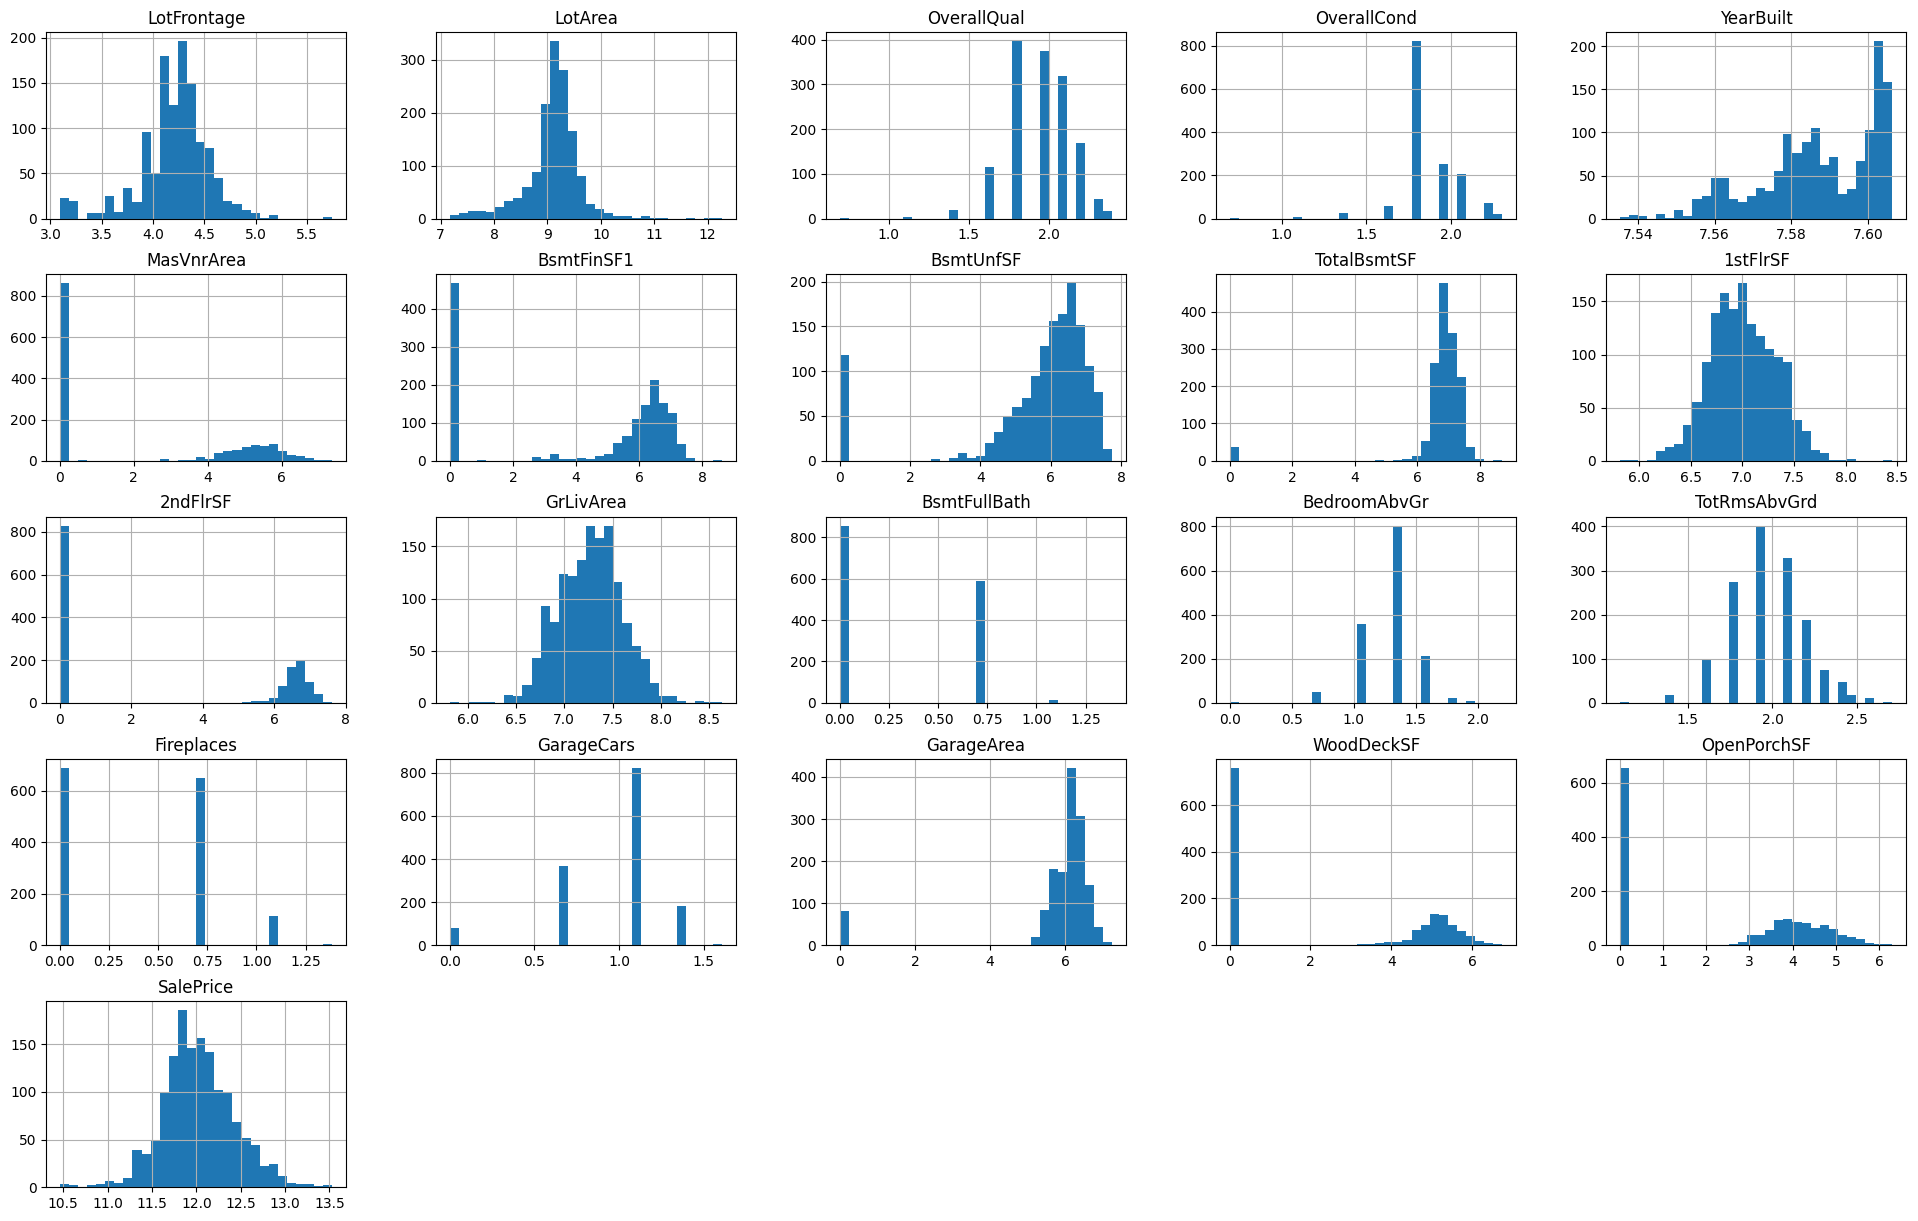

In [20]:
## Since Data is right-skewed -> Log transformation reduces skewness and Reveals structure hidden in the original scale
viz = np.log1p(df[features])
viz.hist(figsize=(24, 15), bins=30)
plt.show()

**Comment** 
1. __MasVnrArea, BsmtFinSF1, BsmtUnfSF, TotalBsmtSF, WoodDeckSF, OpenPorchSF__ :  \
   a. Big values stretch the axis (you ind that Big numbers get squeezed)\
   b. Small values are crowded together (they barely moved)\
   c. The histogram looks like a tall bar on the left and a long tail on the right\
   d. One mean is misleading\
   e. Probably Data entry mistake for high values or represents a Large Luxury Home

Features with outliers: ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'SalePrice']


/tmp/ipykernel_55/1526977943.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=features,


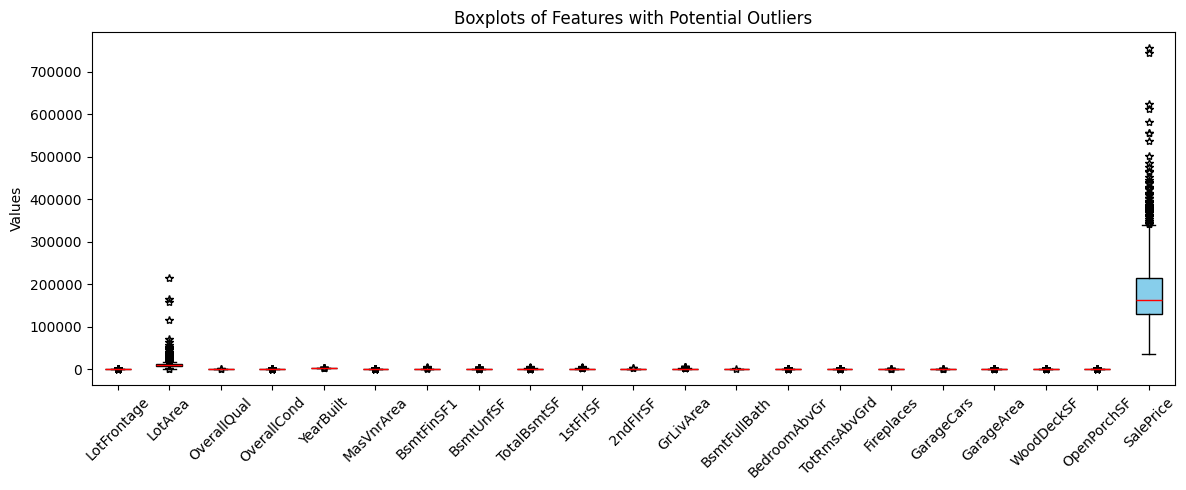

In [21]:
# Features to check
features = list(outliers_dict.keys())
print("Features with outliers:", features)
# Extract the data for boxplots as a list of arrays
data = [df[feat].dropna() for feat in features]

# Create side-by-side boxplots
plt.figure(figsize=(12, 5))
plt.boxplot(data, labels=features, 
            patch_artist=True,
            boxprops=dict(facecolor='skyblue', color='black'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='*', color='orange', markersize=6))  # Customize fliers
plt.title('Boxplots of Features with Potential Outliers')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Comment** 
1. __SalePrice__: The taller the box and whiskers, the more variability
2. __LotArea__: box is small but whiskers reach 215k → huge variance (Spread)

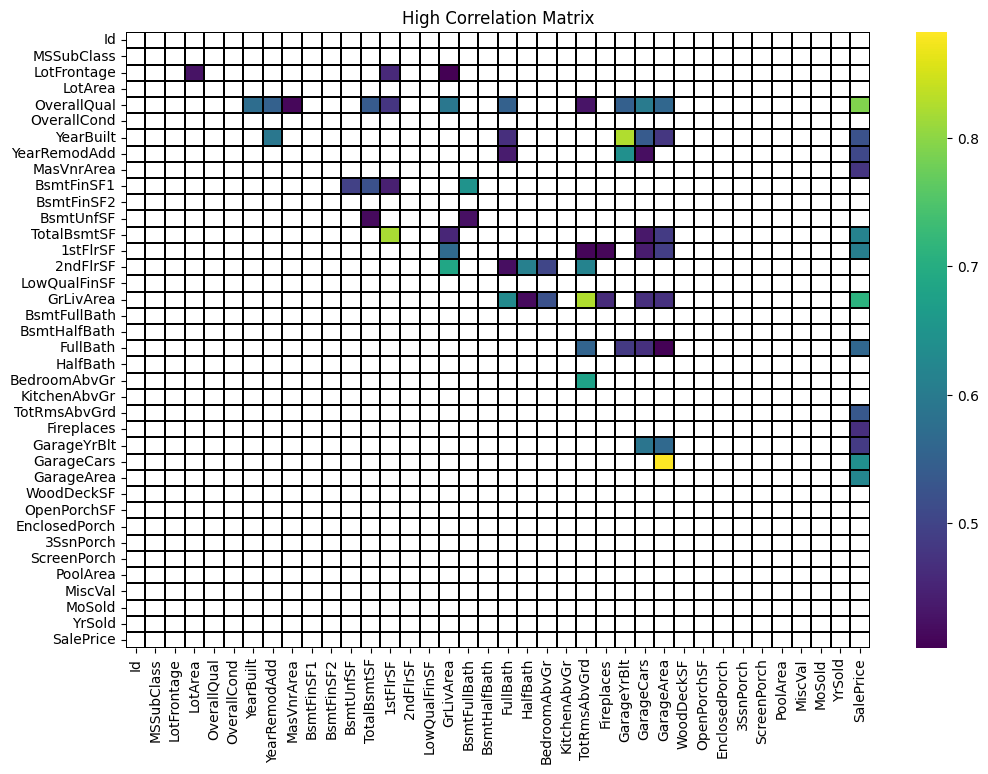

In [22]:
# Features to check
# Compute correlation matrix for all numeric columns
corr_threshold = 0.4
df_num = df.select_dtypes(include=np.number)
corr_matrix = df_num.corr().abs()

# Upper triangle of an array.
corr_arry= np.triu(np.ones(corr_matrix.shape), k=1)
high_corr = corr_matrix.where(corr_arry  > 0)
high_corr = high_corr[high_corr >= corr_threshold]
plt.figure(figsize=(12,8))
sns.heatmap(high_corr, fmt=".2f",
            cmap='viridis',
            linecolor="black",     # grid color
            linewidths=0.2,        # grid thickness
            cbar=True)
plt.title("High Correlation Matrix")
plt.show()

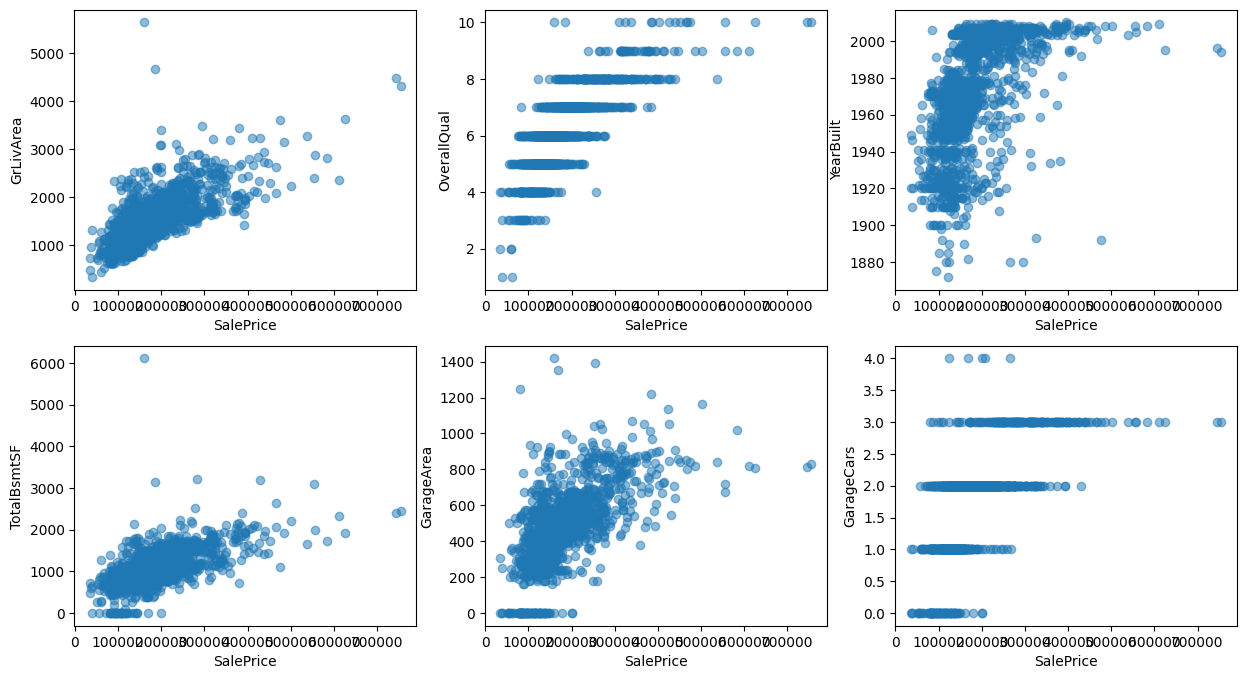

In [23]:
# PLot only the corrlated columns to the Sales Prices
fig, axes = plt.subplots(2, 3, figsize=(15,8))
# GrLivArea is : Above grade (ground) living area square feet
axes[0,0].scatter(df["SalePrice"], df["GrLivArea"], alpha=0.5)
axes[0,0].set_xlabel("SalePrice")
axes[0,0].set_ylabel("GrLivArea")

# OverallQual: Overall material and finish quality
axes[0,1].scatter(df["SalePrice"], df["OverallQual"], alpha=0.5)
axes[0,1].set_xlabel("SalePrice")
axes[0,1].set_ylabel("OverallQual")

# YearBuilt is : 
axes[0,2].scatter(df["SalePrice"], df["YearBuilt"], alpha=0.5)
axes[0,2].set_xlabel("SalePrice")
axes[0,2].set_ylabel("YearBuilt")

# TotalBsmtSF: Total square feet of basement area
axes[1,0].scatter(df["SalePrice"], df["TotalBsmtSF"], alpha=0.5)
axes[1,0].set_xlabel("SalePrice")
axes[1,0].set_ylabel("TotalBsmtSF")

# GarageArea: Size of garage in square feet
axes[1,1].scatter(df["SalePrice"], df["GarageArea"], alpha=0.5)
axes[1,1].set_xlabel("SalePrice")
axes[1,1].set_ylabel("GarageArea")



# GarageCars: Size of garage in car capacity
axes[1,2].scatter(df["SalePrice"], df["GarageCars"], alpha=0.5)
axes[1,2].set_xlabel("SalePrice")
axes[1,2].set_ylabel("GarageCars")


plt.show()

